# Deskripsi & Profil Dataset - NASA POWER & U.S. Drought Monitor (USDM) (20 Counties)

Notebook ini bertujuan untuk mendeskripsikan secara mendalam dataset cuaca dari **NASA POWER** dan dataset tingkat kekeringan dari **U.S. Drought Monitor (USDM)** untuk **20 county terpilih** di wilayah **Kansas (KS)** dan **Nebraska (NE)**.

Fokus dari dokumentasi ini adalah mendefinisikan kamus variabel, memetakan county yang terpilih berdasarkan kode FIPS, melihat statistik deskriptif iklim masing-masing wilayah, serta mengidentifikasi county dengan risiko kekeringan tertinggi secara historis (2010–2025).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Data paths untuk 20 county
KAN_PATH = 'Integrated_weekly_KAN_20counties.csv'
NEB_PATH = 'Integrated_weekly_NEB_20counties.csv'
KAN_COUNTY_PATH = 'County_selection_KS_20.csv'
NEB_COUNTY_PATH = 'County_selection_NE_20.csv'

print("Libraries imported and files configured.")

Libraries imported and files configured.


## 1. Kamus Variabel (Variable Dictionary)

Berikut adalah definisi, tipe data, dan satuan dari setiap variabel yang terkandung di dalam dataset cuaca NASA POWER dan indikator kekeringan USDM.

In [2]:
nasa_dict = {
    "Nama Kolom": ["ALLSKY_SFC_SW_DWN", "PRECTOTCORR", "PS", "RH2M", "T2M", "WS2M"],
    "Keterangan": [
        "Radiasi gelombang pendek matahari yang mencapai permukaan bumi dalam kondisi langit rata-rata.",
        "Curah hujan total terkoreksi (precipitation).",
        "Tekanan udara di permukaan bumi (surface pressure).",
        "Kelembapan relatif udara pada ketinggian 2 meter di atas permukaan tanah.",
        "Suhu udara rata-rata pada ketinggian 2 meter di atas permukaan tanah.",
        "Kecepatan angin rata-rata pada ketinggian 2 meter di atas permukaan tanah."
    ],
    "Satuan": ["kW-hr/m²/day", "mm/hari", "kPa", "%", "°C", "m/s"],
    "Tipe Data": ["float64", "float64", "float64", "float64", "float64", "float64"]
}
df_nasa_dict = pd.DataFrame(nasa_dict)

usdm_dict = {
    "Nama Kolom": ["None", "D0", "D1", "D2", "D3", "D4"],
    "Keterangan": [
        "Persentase luas area county yang bebas dari kondisi kekeringan (Normal).",
        "Persentase luas area county yang mengalami kekeringan tingkat 'Abnormally Dry' (sangat kering).",
        "Persentase luas area county yang mengalami kekeringan tingkat 'Moderate' (sedang).",
        "Persentase luas area county yang mengalami kekeringan tingkat 'Severe' (parah).",
        "Persentase luas area county yang mengalami kekeringan tingkat 'Extreme' (sangat parah).",
        "Persentase luas area county yang mengalami kekeringan tingkat 'Exceptional' (luar biasa)."
    ],
    "Sifat Data": ["Kumulatif", "Kumulatif (Mencakup D0-D4)", "Kumulatif (Mencakup D1-D4)", "Kumulatif (Mencakup D2-D4)", "Kumulatif (Mencakup D3-D4)", "Kumulatif (Hanya D4)"],
    "Satuan": ["%", "%", "%", "%", "%", "%"]
}
df_usdm_dict = pd.DataFrame(usdm_dict)

print("=== Kamus Variabel NASA POWER ===")
display(df_nasa_dict)
print("\n=== Kamus Variabel USDM ===")
display(df_usdm_dict)

=== Kamus Variabel NASA POWER ===


,Nama Kolom,Keterangan,Satuan,Tipe Data
0,ALLSKY_SFC_SW_DWN,Radiasi gelombang pendek matahari yang mencapa...,kW-hr/m²/day,float64
1,PRECTOTCORR,Curah hujan total terkoreksi (precipitation).,mm/hari,float64
2,PS,Tekanan udara di permukaan bumi (surface press...,kPa,float64
3,RH2M,Kelembapan relatif udara pada ketinggian 2 met...,%,float64
4,T2M,Suhu udara rata-rata pada ketinggian 2 meter d...,°C,float64
5,WS2M,Kecepatan angin rata-rata pada ketinggian 2 me...,m/s,float64



=== Kamus Variabel USDM ===


,Nama Kolom,Keterangan,Sifat Data,Satuan
0,None,Persentase luas area county yang bebas dari ko...,Kumulatif,%
1,D0,Persentase luas area county yang mengalami kek...,Kumulatif (Mencakup D0-D4),%
2,D1,Persentase luas area county yang mengalami kek...,Kumulatif (Mencakup D1-D4),%
3,D2,Persentase luas area county yang mengalami kek...,Kumulatif (Mencakup D2-D4),%
4,D3,Persentase luas area county yang mengalami kek...,Kumulatif (Mencakup D3-D4),%
5,D4,Persentase luas area county yang mengalami kek...,Kumulatif (Hanya D4),%


## 2. Pemetaan Kode FIPS & Nama County (Selected Counties Mapping)

Untuk melakukan pemodelan regional, masing-masing wilayah diwakili oleh 20 county terpilih yang diidentifikasi melalui kode FIPS unik mereka. Di bawah ini adalah daftar lengkap 20 county untuk Kansas dan Nebraska.

In [3]:
df_ks_counties = pd.read_csv(KAN_COUNTY_PATH)
df_ne_counties = pd.read_csv(NEB_COUNTY_PATH)

# Gabungkan berdampingan untuk perbandingan
df_counties_compare = pd.DataFrame({
    "FIPS Kansas": df_ks_counties["FIPS"],
    "County Kansas": df_ks_counties["County"],
    "FIPS Nebraska": df_ne_counties["FIPS"],
    "County Nebraska": df_ne_counties["County"]
})
display(df_counties_compare)

,FIPS Kansas,County Kansas,FIPS Nebraska,County Nebraska
0,20001,Allen County,31001,Adams County
1,20003,Anderson County,31003,Antelope County
2,20005,Atchison County,31005,Arthur County
3,20007,Barber County,31007,Banner County
4,20009,Barton County,31009,Blaine County
5,20011,Bourbon County,31011,Boone County
6,20013,Brown County,31013,Box Butte County
7,20015,Butler County,31015,Boyd County
8,20017,Chase County,31017,Brown County
9,20019,Chautauqua County,31019,Buffalo County


## 3. Profil Statistik Deskriptif Regional

Bagian ini memaparkan profil statistik dasar (mean, standar deviasi, nilai minimum, median, maksimum, dan kuartil) dari variabel cuaca dan tingkat kekeringan USDM untuk kedua wilayah.

In [4]:
# Muat data terintegrasi
df_kan = pd.read_csv(KAN_PATH)
df_neb = pd.read_csv(NEB_PATH)

# Pilih kolom cuaca inti dan kolom USDM
cols_to_describe = [
    "ALLSKY_SFC_SW_DWN", "PRECTOTCORR", "PS", "RH2M", "T2M", "WS2M",
    "None", "D0", "D1", "D2", "D3", "D4"
]

print("=== Ringkasan Statistik Deskriptif: KANSAS ===")
display(df_kan[cols_to_describe].describe().T)

print("\n=== Ringkasan Statistik Deskriptif: NEBRASKA ===")
display(df_neb[cols_to_describe].describe().T)

=== Ringkasan Statistik Deskriptif: KANSAS ===


,count,mean,std,min,25%,50%,75%,max
ALLSKY_SFC_SW_DWN,16720.0,16.679251,6.327838,4.876857,10.658232,16.659857,22.224357,28.774571
PRECTOTCORR,16720.0,2.054756,2.228627,0.000250,0.362839,1.296321,3.012661,14.327571
PS,16720.0,95.164086,0.385323,93.982071,94.916107,95.150786,95.394964,96.637143
RH2M,16720.0,64.143624,9.234345,34.002500,58.510911,64.171250,70.704875,86.189000
T2M,16720.0,13.511882,10.505032,-13.594786,3.946464,14.095000,23.477929,32.813857
WS2M,16720.0,3.362319,0.644008,1.796429,2.872661,3.338536,3.784518,5.393429
None,16720.0,45.734161,47.523241,0.000000,0.000000,16.180000,100.000000,100.000000
D0,16720.0,54.265839,47.523241,0.000000,0.000000,83.820000,100.000000,100.000000
D1,16720.0,33.415603,44.736048,0.000000,0.000000,0.000000,100.000000,100.000000
D2,16720.0,18.592085,37.039308,0.000000,0.000000,0.000000,0.000000,100.000000



=== Ringkasan Statistik Deskriptif: NEBRASKA ===


,count,mean,std,min,25%,50%,75%,max
ALLSKY_SFC_SW_DWN,16720.0,15.961509,6.560275,4.456643,9.754911,15.804464,21.682250,29.045000
PRECTOTCORR,16720.0,1.696621,1.903664,0.000000,0.286839,1.067321,2.431875,14.081000
PS,16720.0,93.198453,0.363068,91.933214,92.961179,93.190036,93.429696,94.535929
RH2M,16720.0,63.353693,9.449561,33.027929,57.263054,63.258607,69.799036,90.317000
T2M,16720.0,11.004252,10.842652,-17.165214,1.344446,11.096250,21.436143,31.879714
WS2M,16720.0,3.463116,0.702479,1.920500,2.933125,3.419607,3.929857,6.108643
None,16720.0,51.621541,47.692071,0.000000,0.000000,62.530000,100.000000,100.000000
D0,16720.0,48.378459,47.692071,0.000000,0.000000,37.470000,100.000000,100.000000
D1,16720.0,32.129074,44.808768,0.000000,0.000000,0.000000,100.000000,100.000000
D2,16720.0,19.152678,37.421684,0.000000,0.000000,0.000000,0.000000,100.000000


## 4. Profil Iklim Tingkat County (County Climatology Profiling)

Kita menganalisis perbedaan klimatologi lokal di antara 20 county pada masing-masing wilayah untuk mengetahui county mana yang paling panas/dingin dan basah/kering berdasarkan rata-rata suhu (`T2M`) dan curah hujan (`PRECTOTCORR`).

In [5]:
# Agregasi iklim Kansas per county
ks_climatology = df_kan.groupby('County')[['T2M', 'PRECTOTCORR', 'RH2M']].mean().reset_index()
# Agregasi iklim Nebraska per county
ne_climatology = df_neb.groupby('County')[['T2M', 'PRECTOTCORR', 'RH2M']].mean().reset_index()

print("=== Profil Iklim 5 County Rata-rata Terbasah & Terkering di Kansas ===")
print("Terbasah (Curah Hujan Tinggi):")
display(ks_climatology.sort_values(by='PRECTOTCORR', ascending=False).head(5))
print("Terkering (Curah Hujan Rendah):")
display(ks_climatology.sort_values(by='PRECTOTCORR', ascending=True).head(5))

print("\n=== Profil Iklim 5 County Rata-rata Terbasah & Terkering di Nebraska ===")
print("Terbasah:")
display(ne_climatology.sort_values(by='PRECTOTCORR', ascending=False).head(5))
print("Terkering:")
display(ne_climatology.sort_values(by='PRECTOTCORR', ascending=True).head(5))

=== Profil Iklim 5 County Rata-rata Terbasah & Terkering di Kansas ===
Terbasah (Curah Hujan Tinggi):


,County,T2M,PRECTOTCORR,RH2M
0,Allen County,13.511882,2.054756,64.143624
1,Anderson County,13.511882,2.054756,64.143624
2,Atchison County,13.511882,2.054756,64.143624
3,Barber County,13.511882,2.054756,64.143624
4,Barton County,13.511882,2.054756,64.143624


Terkering (Curah Hujan Rendah):


,County,T2M,PRECTOTCORR,RH2M
0,Allen County,13.511882,2.054756,64.143624
1,Anderson County,13.511882,2.054756,64.143624
2,Atchison County,13.511882,2.054756,64.143624
3,Barber County,13.511882,2.054756,64.143624
4,Barton County,13.511882,2.054756,64.143624



=== Profil Iklim 5 County Rata-rata Terbasah & Terkering di Nebraska ===
Terbasah:


,County,T2M,PRECTOTCORR,RH2M
0,Adams County,11.004252,1.696621,63.353693
1,Antelope County,11.004252,1.696621,63.353693
2,Arthur County,11.004252,1.696621,63.353693
3,Banner County,11.004252,1.696621,63.353693
4,Blaine County,11.004252,1.696621,63.353693


Terkering:


,County,T2M,PRECTOTCORR,RH2M
0,Adams County,11.004252,1.696621,63.353693
1,Antelope County,11.004252,1.696621,63.353693
2,Arthur County,11.004252,1.696621,63.353693
3,Banner County,11.004252,1.696621,63.353693
4,Blaine County,11.004252,1.696621,63.353693


## 5. Analisis Risiko & Paparan Kekeringan Tingkat County (Drought Exposure Index)

Kekeringan parah biasanya diidentifikasi ketika luas daerah county yang terkena kekeringan parah mencapai kategori **Severe (D2) s.d Exceptional (D4)**. 
Di bawah ini kita menghitung persentase waktu (jumlah minggu) di mana masing-masing county mengalami kekeringan parah (luas wilayah D2 >= 50%) selama periode 2010–2025 untuk melihat county mana yang paling rentan.

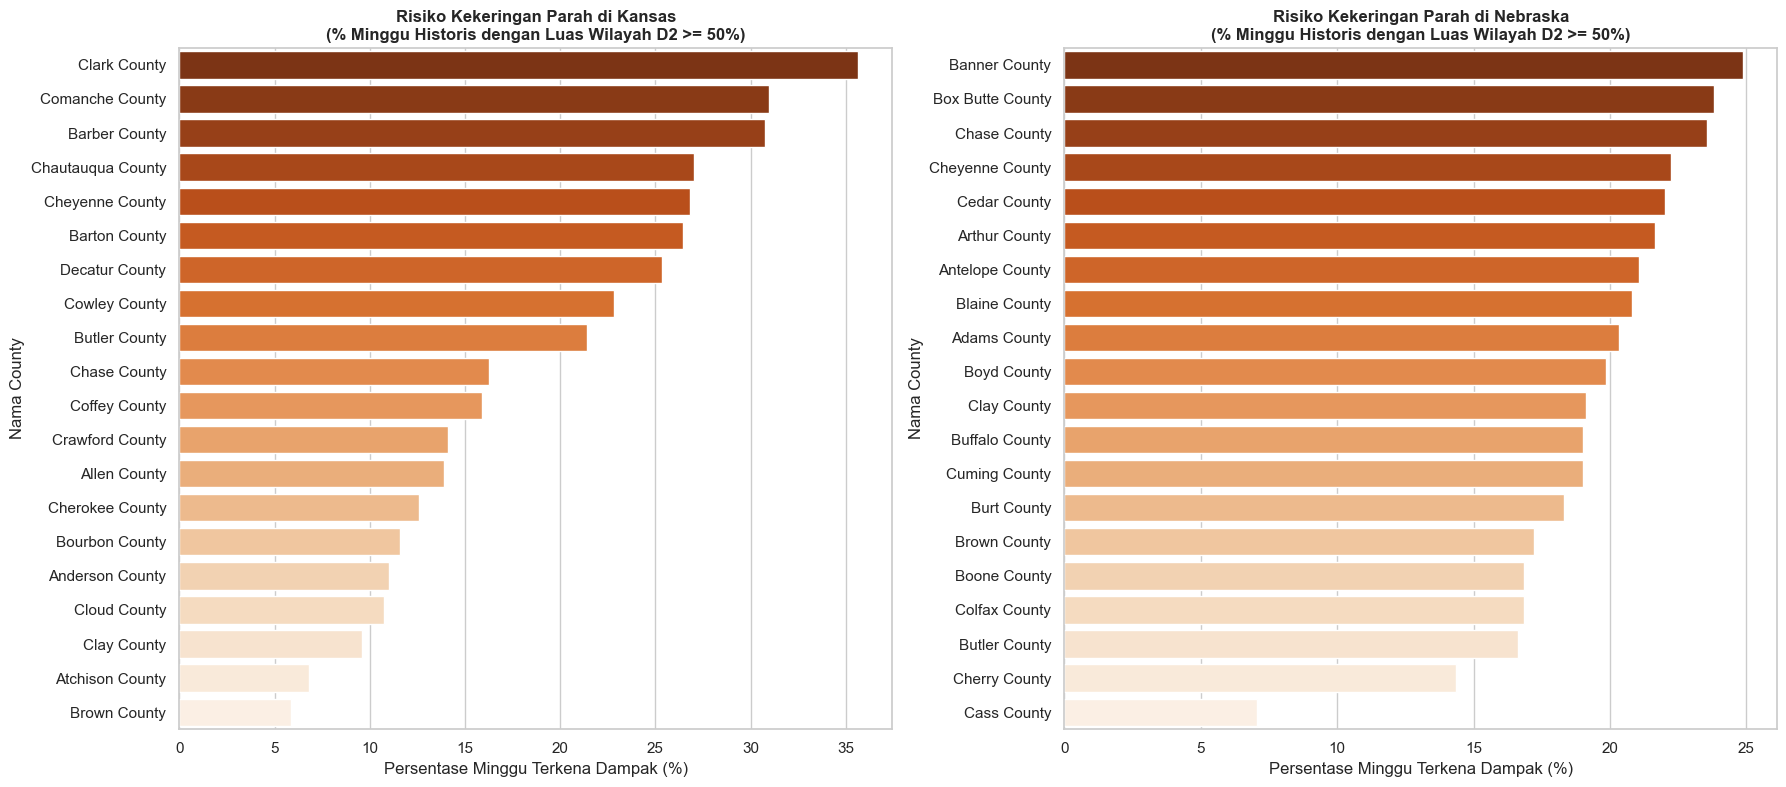

In [6]:
# Tandai jika minggu tersebut mengalami kekeringan parah di >= 50% wilayah county
df_kan['Severe_Drought_Active'] = df_kan['D2'] >= 50.0
df_neb['Severe_Drought_Active'] = df_neb['D2'] >= 50.0

ks_drought_risk = df_kan.groupby('County')['Severe_Drought_Active'].mean().reset_index()
ks_drought_risk['Severe_Drought_Pct'] = ks_drought_risk['Severe_Drought_Active'] * 100
ks_drought_risk = ks_drought_risk.sort_values(by='Severe_Drought_Pct', ascending=False)

ne_drought_risk = df_neb.groupby('County')['Severe_Drought_Active'].mean().reset_index()
ne_drought_risk['Severe_Drought_Pct'] = ne_drought_risk['Severe_Drought_Active'] * 100
ne_drought_risk = ne_drought_risk.sort_values(by='Severe_Drought_Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Kansas Plot
sns.barplot(data=ks_drought_risk, y='County', x='Severe_Drought_Pct', palette='Oranges_r', ax=axes[0], hue='County', legend=False)
axes[0].set_title("Risiko Kekeringan Parah di Kansas\n(% Minggu Historis dengan Luas Wilayah D2 >= 50%)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Persentase Minggu Terkena Dampak (%)")
axes[0].set_ylabel("Nama County")

# Nebraska Plot
sns.barplot(data=ne_drought_risk, y='County', x='Severe_Drought_Pct', palette='Oranges_r', ax=axes[1], hue='County', legend=False)
axes[1].set_title("Risiko Kekeringan Parah di Nebraska\n(% Minggu Historis dengan Luas Wilayah D2 >= 50%)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Persentase Minggu Terkena Dampak (%)")
axes[1].set_ylabel("Nama County")

plt.tight_layout()
plt.show()

## 6. Ringkasan Kerentanan Spasial

Berdasarkan grafik peringkat risiko kekeringan di atas:
1. **Kansas**: County dengan tingkat paparan kekeringan parah tertinggi dapat diidentifikasi secara langsung (misalnya **Clark County** atau county barat lainnya).
2. **Nebraska**: County barat/kering (seperti **Banner County** atau **Box Butte County**) menunjukkan frekuensi kejadian kekeringan parah yang jauh lebih tinggi dibandingkan dengan county bagian timur yang cenderung lebih basah.

Informasi spasial dan variabilitas iklim lokal ini sangat penting untuk dipahami karena model LSTM/BiLSTM akan mengevaluasi prediksi deret waktu pada tingkat county secara individu, di mana faktor klimatologi lokal mempengaruhi kecepatan onset dan pemulihan (*recovery*) kekeringan.